In [28]:
import copy

import numpy as np
import matplotlib.pyplot as plt

import srwave

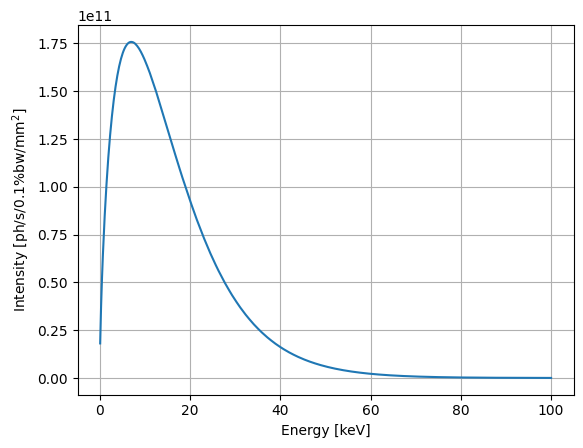

In [2]:
energy = np.linspace(0.1,100,500)*1e3

bm = srwave.me.BendingMagnet(B=1.4,L=3)
fields = srwave.me.MagnetCnt(magnets=[bm],field_type='bending')

SR = srwave.rad.SynchrotronRadiation(energy=energy,d=10,x=0,y=0,fields=fields)
SR.calc_wfr()

arrI, [rangee] = SR.calc_intensity(coords='e',energy=0,X=0,Y=0,polarization='total',intType='SE')

plt.plot(energy*1e-3,arrI)
plt.xlabel('Energy [keV]')
plt.ylabel(r'Intensity [ph/s/0.1%bw/mm$^2$]')
plt.grid()
plt.show()

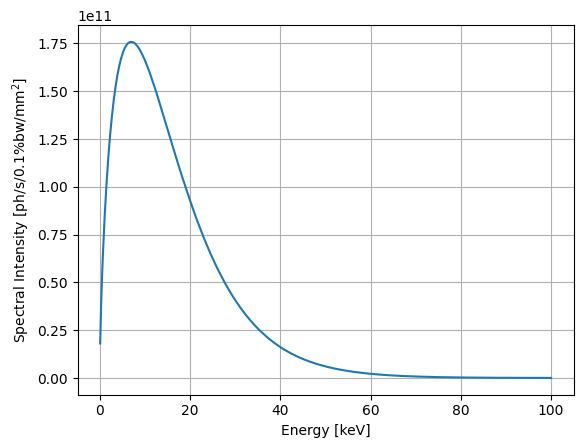

In [2]:
energy = np.linspace(0.1,100,500)*1e3

bm = srwave.me.BendingMagnet(B=1.4,L=3)
fields = srwave.me.MagnetCnt(magnets=[bm],field_type='bending')

SR = srwave.rad.SynchrotronRadiation(energy=energy,d=10,x=0,y=0,fields=fields)
SR.calc_wfr()

SR.plot_spectrum()

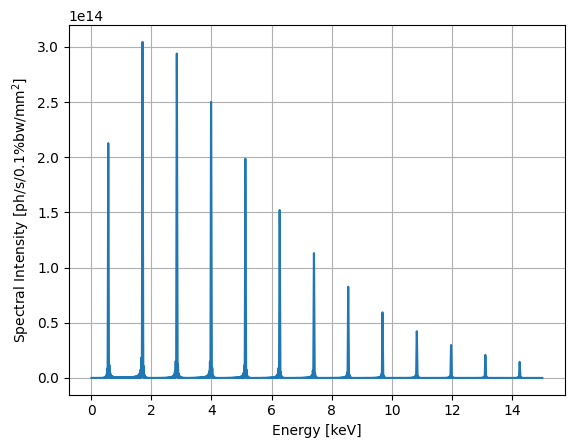

In [3]:
und = srwave.me.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = srwave.me.MagnetCnt(magnets=[und],field_type='undulator')

energy = np.linspace(0.01,15,7000)*1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy,E=3e9,theta=0)

SR = srwave.rad.SynchrotronRadiation(energy=energy,d=10,x=0,y=0,fields=fields)
SR.calc_wfr()

SR.plot_spectrum()

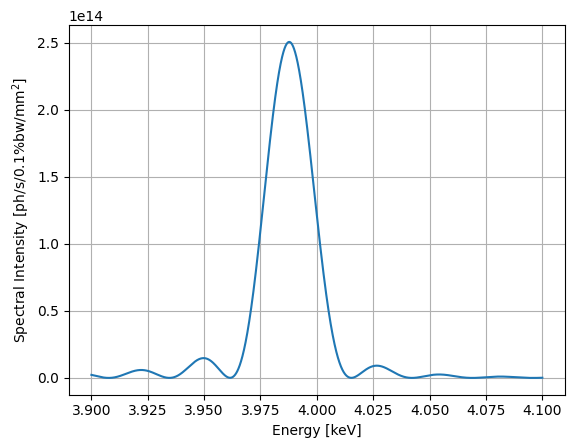

In [4]:
und = srwave.me.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = srwave.me.MagnetCnt(magnets=[und],field_type='undulator')

energy = np.linspace(4-0.1,4+0.1,7000)*1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy,E=3e9,theta=0)

SR = srwave.rad.SynchrotronRadiation(energy=energy,d=10,x=0,y=0,fields=fields)
SR.calc_wfr()

SR.plot_spectrum()

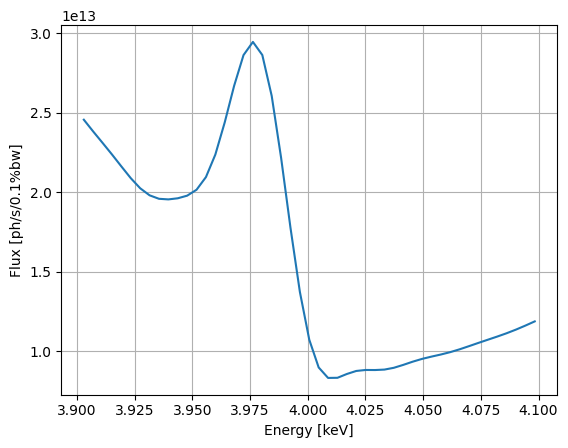

In [5]:
und = srwave.me.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = srwave.me.MagnetCnt(magnets=[und],field_type='undulator')

w = np.linspace(-5e-4,5e-4,200)
energy = np.linspace(4-0.1,4+0.1,50)*1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy,E=3e9,theta=0)

SR = srwave.rad.SynchrotronRadiation(energy=energy,d=5,x=w,y=w,fields=fields)
SR.calc_wfr()

arrF, [rangee] = SR.calc_flux(polarization='total',intType='SE')

plt.plot(energy*1e-3,arrF)
plt.xlabel('Energy [keV]')
plt.ylabel(r'Flux [ph/s/0.1%bw]')
plt.grid()
plt.show()

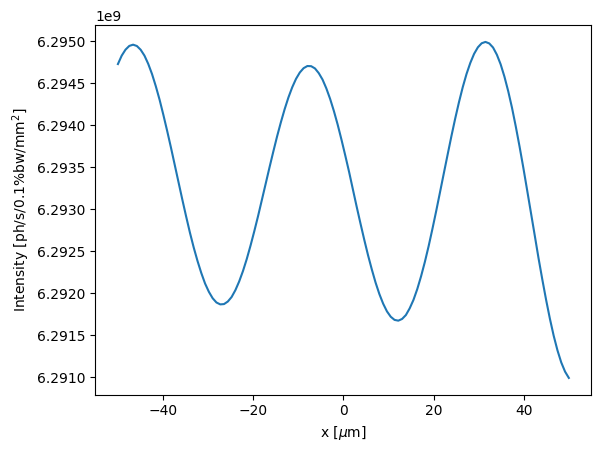

In [6]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = srwave.me.BendingMagnet(B=0.5642,L=3)
fields = srwave.me.MagnetCnt(magnets=[bm],field_type='bending')

SR = srwave.rad.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

arrI, [rangex] = SR.calc_intensity(coords='x',energy=0,X=0,Y=0,polarization='total',intType='SE')
x = np.linspace(*rangex)*1e6

plt.plot(x,arrI)
plt.xlabel(r'x [$\mu$m]')
plt.ylabel(r'Intensity [ph/s/0.1%bw/mm$^2$]')
plt.show()

#OBS: Notice the scale of variation of the intensity. The oscillation is result of accumulation of numerical errors, the intensity is almost constant or constant varying

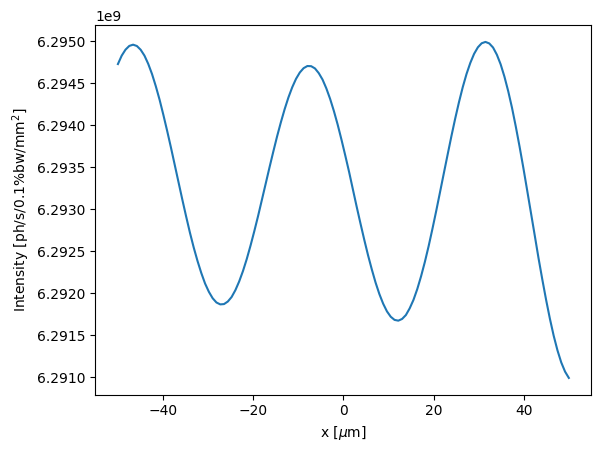

In [7]:
SR.plot_intensity(coords='x',energy=Eph,X=0,Y=0,intType='SE',
                    xlabel=r'x [$\mu$m]',ylabel=r'Intensity [ph/s/0.1%bw/mm$^2$]')

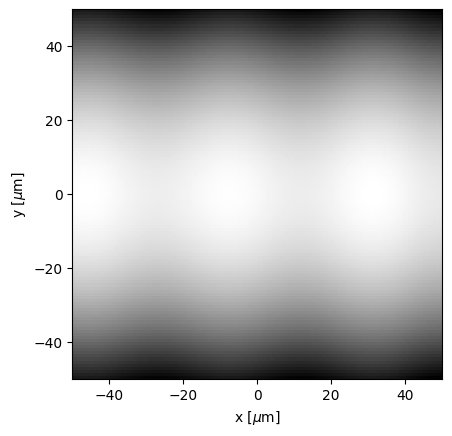

In [8]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = srwave.me.BendingMagnet(B=0.5642,L=3)
fields = srwave.me.MagnetCnt(magnets=[bm],field_type='bending')

SR = srwave.rad.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

SR.plot_intensity(coords='xy',energy=Eph,X=0,Y=0,intType='SE',
                    xlabel=r'x [$\mu$m]',ylabel=r'y [$\mu$m]')

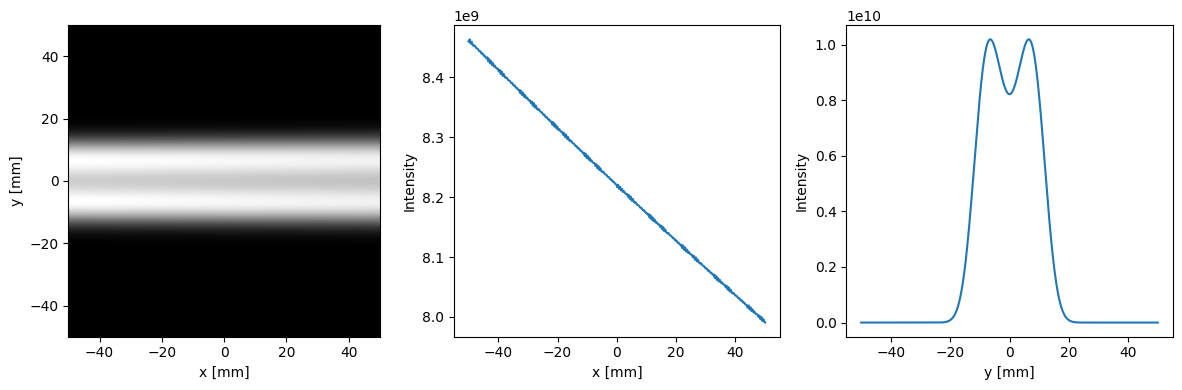

In [9]:
bm = srwave.me.BendingMagnet(B=1.4,L=4)
fields = srwave.me.MagnetCnt(magnets=[bm],field_type='bending')

Eph = srwave.uti.wavelength_to_energy(325e-9)
w = np.linspace(-50,50,100)*1e-3

SR = srwave.rad.SynchrotronRadiation(energy=Eph,d=5,x=w,y=w,fields=fields)
SR.precisions['sampling'] = 0.1
SR.calc_wfr()


plt.figure(figsize=(12,4))
ax1 = plt.subplot(1,3,1)
ax2 = plt.subplot(1,3,2)
ax3 = plt.subplot(1,3,3)

SR.plot_intensity(coords='xy',energy=Eph,X=0,Y=0, ax=ax1, aspect='equal',
                    xlabel='x [mm]',ylabel='y [mm]',unit='mm')
SR.plot_intensity(coords='x',energy=Eph,X=0,Y=0, ax=ax2,
                    xlabel='x [mm]',ylabel='Intensity',unit='mm')
SR.plot_intensity(coords='y',energy=Eph,X=0,Y=0, ax=ax3,
                    xlabel='y [mm]',ylabel='Intensity',unit='mm')

plt.tight_layout()
plt.show()

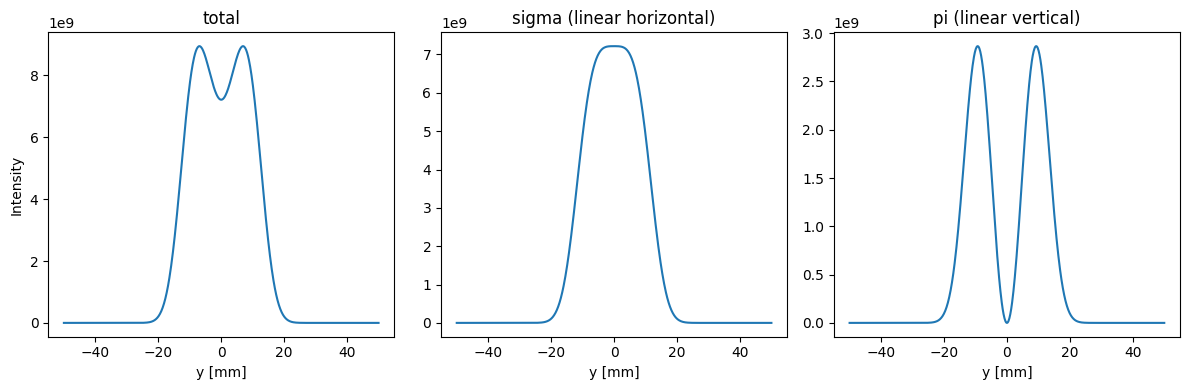

In [10]:
bm = srwave.me.BendingMagnet(B=1.4,L=4)
fields = srwave.me.MagnetCnt(magnets=[bm],field_type='bending')

Eph = srwave.uti.wavelength_to_energy(325e-9)
w = np.linspace(-50,50,100)*1e-3

SR = srwave.rad.SynchrotronRadiation(energy=Eph,d=5.336,x=w,y=w,fields=fields)
SR.precisions['sampling'] = 0.1
SR.calc_wfr()


plt.figure(figsize=(12,4))
ax1 = plt.subplot(1,3,1)
ax2 = plt.subplot(1,3,2)
ax3 = plt.subplot(1,3,3)

SR.plot_intensity(coords='y',energy=Eph,X=0,Y=0,polarization='total',ax=ax1,
                    title='total',xlabel='y [mm]',ylabel='Intensity',unit='mm')
SR.plot_intensity(coords='y',energy=Eph,X=0,Y=0,polarization='linH',ax=ax2,
                    title='sigma (linear horizontal)',xlabel='y [mm]',unit='mm')
SR.plot_intensity(coords='y',energy=Eph,X=0,Y=0,polarization='linV',ax=ax3,
                    title='pi (linear vertical)',xlabel='y [mm]',unit='mm')

plt.tight_layout()
plt.show()

In [11]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = srwave.me.BendingMagnet(B=0.5642,L=3)
fields = srwave.me.MagnetCnt(magnets=[bm],field_type='bending')

SR = srwave.rad.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

arrP, [rangex, rangey] = SR.calc_electric_field(part='phase',coords='xy',energy=0,X=0,Y=0)
xi, xf, nx, yi, yf, ny = *rangex, *rangey
arrP = np.array(arrP).reshape(ny,nx)

limits = SR.window_limits() * 1e6

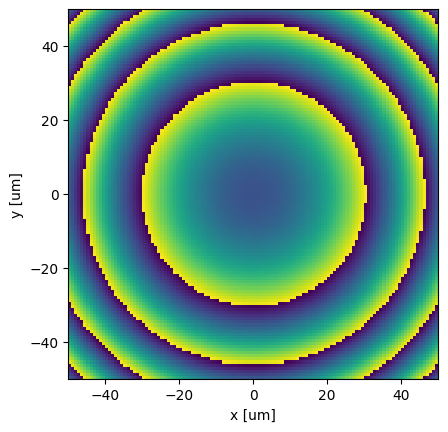

In [12]:
plt.imshow(arrP,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

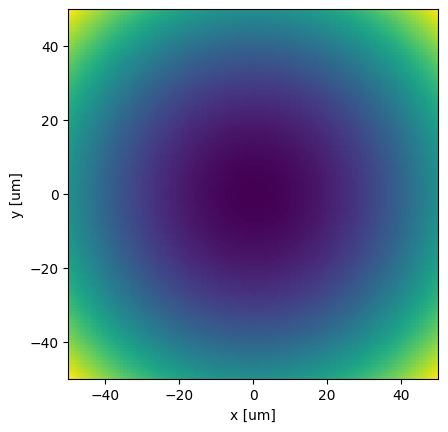

In [13]:
arrP_unw = srwave.rad.SynchrotronRadiation.unwrap_phase(arrP)

plt.imshow(arrP_unw,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

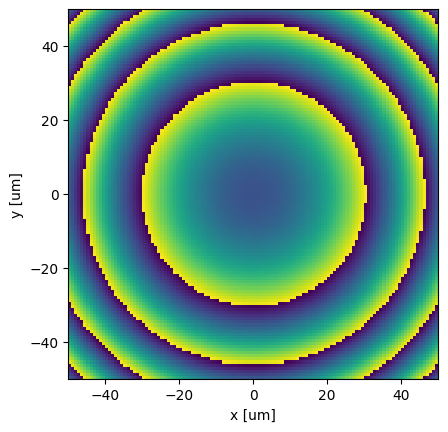

In [14]:
arrP_w = srwave.rad.SynchrotronRadiation.wrap_phase(arrP_unw)

plt.imshow(arrP_w,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

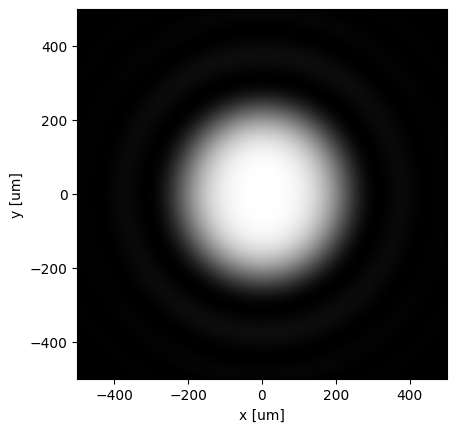

In [15]:
und = srwave.me.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = srwave.me.MagnetCnt(magnets=[und],field_type='undulator')

w = np.linspace(-5e-4,5e-4,200)
Eph = und.harmonic_energy(harmn=1,E=3e9,theta=0)

SR = srwave.rad.SynchrotronRadiation(energy=Eph,d=5,x=w,y=w,fields=fields)
SR.calc_wfr()

arrI, [rangex,rangey] = SR.calc_intensity(coords='xy',energy=SR.wfr.mesh.eStart,X=0,Y=0,polarization='total',intType='SE')
xi, xf, nx, yi, yf, ny = *rangex, *rangey
arrI = np.array(arrI).reshape(ny,nx)

limits = SR.window_limits() * 1e6
plt.imshow(arrI,cmap='gray',extent=limits)
plt.ylabel('y [um]')
plt.xlabel('x [um]')
plt.show()

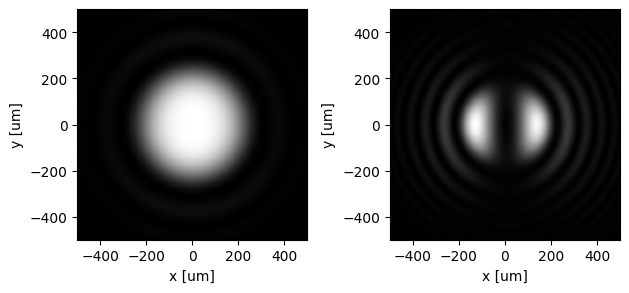

In [16]:
und = srwave.me.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = srwave.me.MagnetCnt(magnets=[und],field_type='undulator')

w = np.linspace(-5e-4,5e-4,200)
Eph1 = und.harmonic_energy(harmn=1,E=3e9,theta=0)
Eph2 = und.harmonic_energy(harmn=2,E=3e9,theta=0)

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)

for ax, Eph in zip([ax1,ax2],[Eph1,Eph2]):

    SR = srwave.rad.SynchrotronRadiation(energy=Eph,d=5,x=w,y=w,fields=fields)
    SR.calc_wfr()

    arrI, [rangex,rangey] = SR.calc_intensity(coords='xy',energy=SR.wfr.mesh.eStart,X=0,Y=0,polarization='total',intType='SE')
    xi, xf, nx, yi, yf, ny = *rangex, *rangey
    arrI = np.array(arrI).reshape(ny,nx)

    limits = SR.window_limits() * 1e6
    ax.imshow(arrI,cmap='gray',extent=limits)
    ax.set_ylabel('y [um]')
    ax.set_xlabel('x [um]')

plt.tight_layout()
plt.show()

In [2]:
drift = srwave.oe.Drift(distance=10)

In [3]:
drift = srwave.oe.Drift(distance=10)
drift.prop_params['propagator'] = 'Quadratic'
drift.prop_params['ra'] = 4 # horizontal and vertical range factors
drift.prop_params['re'] = 2 # horizontal and vertical resolution factors
drift.prop_params['re_v'] = 3 # vertical resolution factor
drift.prop_params['auto_rs_before'] = True # resize wavefront before propagation
# ...

# check the current parameters of some optical element
print(drift.prop_params)

auto_rs_before : True
auto_rs_after  : False
auto_rs_prec   : 1.0
propagator     : 1
rs             : False
ra_h           : 4
re_h           : 2
ra_v           : 4
re_v           : 3
p1             : 0
p2             : 0
p3             : 0



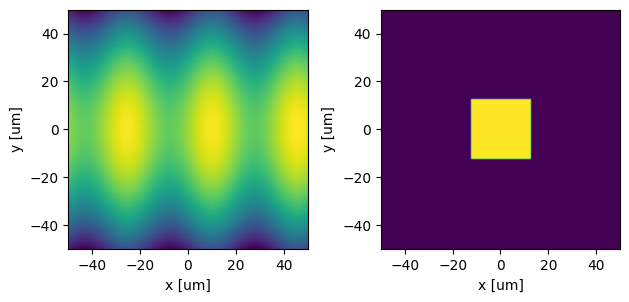

In [4]:
Eph = 22e3

w = np.linspace(-50,50,120)*1e-6

bm = srwave.me.BendingMagnet(B=0.5642,L=3)
fields = srwave.me.MagnetCnt(magnets=[bm],field_type='bending')

SR = srwave.rad.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

ax1 = plt.subplot(121)
SR.plot_intensity(coords='xy',energy=Eph,X=0,Y=0,
                    ax=ax1, cmap='viridis', xlabel='x [um]', ylabel='y [um]')


apert = 25e-6

aper = srwave.oe.Slit(apert,apert)

bl = srwave.rad.Beamline(line=[aper])
SR.propagate_wfr(beamline=bl)

ax2 = plt.subplot(122)
SR.plot_intensity(coords='xy',energy=Eph,X=0,Y=0,
                    ax=ax2, cmap='viridis', xlabel='x [um]', ylabel='y [um]')

plt.tight_layout()
plt.show()

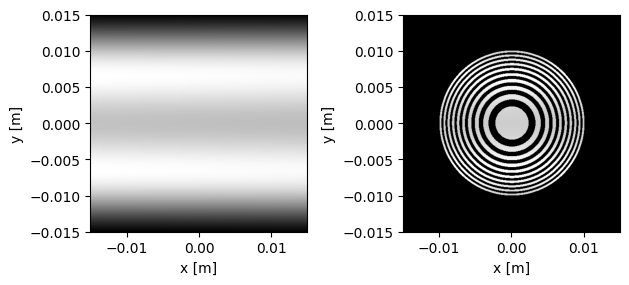

In [6]:
bm = srwave.me.BendingMagnet(B=1.4,L=3)
fields = srwave.me.MagnetCnt(magnets=[bm],field_type='bending')

w = np.linspace(-15,15,500)*1e-3

SR = srwave.rad.SynchrotronRadiation(energy=3.8,d=5,x=w,y=w,fields=fields)
SR.calc_wfr()

ax1 = plt.subplot(121)
SR.plot_intensity(coords='xy',energy=Eph,X=0,Y=0,
                    ax=ax1, unit='m', xlabel='x [m]', ylabel='y [m]')


zp = srwave.oe.FresnelZonePlate(nr_zones=19,radius_n=0.01)
bl = srwave.rad.Beamline(line=[zp])
SR.propagate_wfr(beamline=bl)


ax2 = plt.subplot(122)
SR.plot_intensity(coords='xy',energy=Eph,X=0,Y=0,
                    ax=ax2, unit='m', xlabel='x [m]', ylabel='y [m]')

plt.tight_layout()
plt.show()

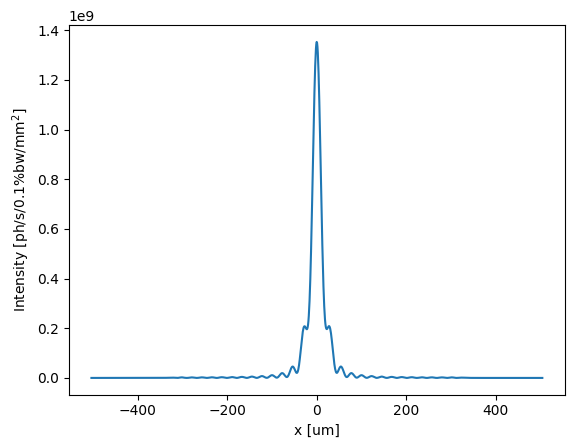

In [7]:
Eph = 22e3
apert = 25e-6
w = np.linspace(-50,50,120)*1e-6

bm = srwave.me.BendingMagnet(B=0.5642,L=3)
fields = srwave.me.MagnetCnt(magnets=[bm],field_type='bending')

SR = srwave.rad.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

filtro = srwave.oe.AbsorptionFilter(x=w,y=w,energy=Eph,thickness=1e-3,material='Al')
aper = srwave.oe.Slit(apert,apert)
aper.prop_params['ra'] = 10.0
screen = srwave.oe.Drift(distance=10)
bl = srwave.rad.Beamline(line=[filtro,aper,screen])
SR.propagate_wfr(beamline=bl)

arrIx, [rangex] = SR.calc_intensity(coords='x',energy=Eph,X=0,Y=0,polarization='total',intType='SE')
x = np.linspace(*rangex)*1e6

plt.plot(x,arrIx)
plt.xlabel('x [um]')
plt.ylabel(r'Intensity [ph/s/0.1%bw/mm$^2$]')
plt.show()

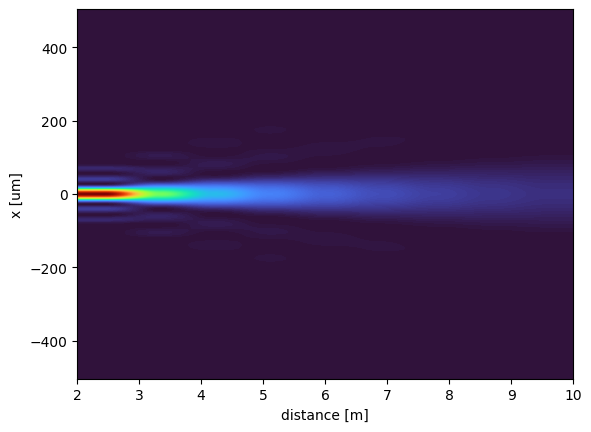

In [2]:
Eph = 17.5e3
w = np.linspace(-50,50,120)*1e-6
apert = 5e-6

bm = srwave.me.BendingMagnet(B=0.5642,L=2)
fields = srwave.me.MagnetCnt(magnets=[bm],field_type='bending')

SR = srwave.rad.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

filtro = srwave.oe.AbsorptionFilter(x=w,y=w,energy=Eph,thickness=1e-3,material='Al')
aper = srwave.oe.Slit(apert,apert)
aper.prop_params['ra'] = 10.0
# screen = Slit(dist=d)
# bl = Beamline(line=[filtro,aper,screen])
bl = srwave.rad.Beamline(line=[filtro,aper])
SR.propagate_wfr(beamline=bl)


distances = np.linspace(2,10,9)

arrsI, ranges = srwave.beamlines.caustic(SR,dists=distances,coord='x',energy=Eph,X=0,Y=0)

limits = [distances[0],distances[-1],ranges[0][0]*1e6,ranges[0][1]*1e6]
plt.imshow(arrsI,extent=limits,aspect='auto',cmap='turbo')
plt.ylabel('x [um]')
plt.xlabel('distance [m]')
plt.show()

In [104]:
w = np.linspace(-50,50,1000) * 1e-6

GR = srwave.rad.GaussianRadiation(energy=8000, x=w, y=w, d=-3)
GR.gaussianbeam.set_waist(sigX=7e-6/2.355,sigY=7e-6/2.355,sigT=10e-15)
GR.gaussianbeam.set_mode(modex=1,modey=0)
GR.precisions['sampling'] = 3
GR.calc_wfr()

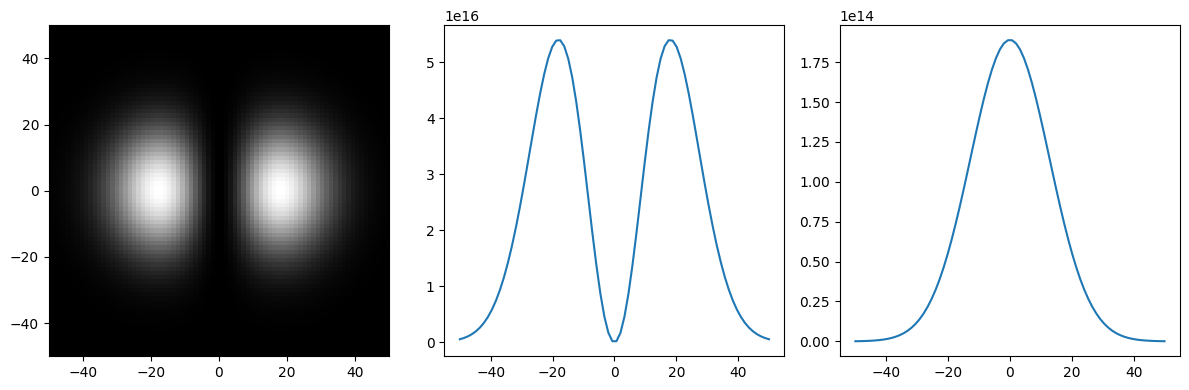

In [105]:
plt.figure(figsize=(12,4))

ax_xy = plt.subplot(1,3,1)
ax_x = plt.subplot(1,3,2)
ax_y = plt.subplot(1,3,3)

GR.plot_intensity(coords='xy',ax=ax_xy,aspect='auto')
GR.plot_intensity(coords='x',ax=ax_x)
GR.plot_intensity(coords='y',ax=ax_y)

plt.tight_layout()
plt.show()

In [101]:
dists = np.linspace(0.5,6,200)

arrsIx = []
arrsIy = []

for dist in dists:
    GRcopy = copy.deepcopy(GR)

    space = srwave.oe.Drift(distance=dist)
    bl = srwave.rad.Beamline(line=space)
    GRcopy.propagate_wfr(beamline=bl)

    (arrIx, [rangex]), (arrIy, [rangey]) = GRcopy.calc_intensity(coords='x-y',energy=GRcopy.gaussianbeam.avgPhotEn,
                                            X=0,Y=0)

    arrsIx.append(arrIx)
    arrsIy.append(arrIy)

arrsIx = np.array(arrsIx).T
arrsIy = np.array(arrsIy).T

maxsx = np.max(arrsIx, axis=0)
maxsy = np.max(arrsIy, axis=0)

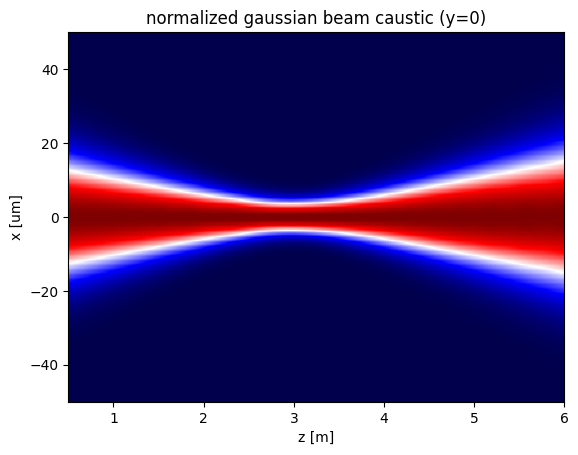

In [102]:
limits = [dists[0], dists[-1], rangex[0]*1e6, rangex[1]*1e6]

plt.imshow(arrsIx/maxsx, extent=limits, aspect='auto', cmap='seismic')
plt.title('normalized gaussian beam caustic (y=0)')
plt.xlabel('z [m]')
plt.ylabel('x [um]')

plt.show()

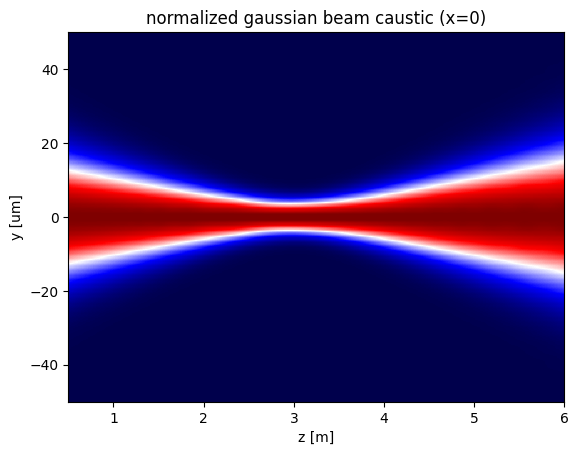

In [103]:
limits = [dists[0], dists[-1], rangey[0]*1e6, rangey[1]*1e6]

plt.imshow(arrsIy/maxsy, extent=limits, aspect='auto', cmap='seismic')
plt.title('normalized gaussian beam caustic (x=0)')
plt.xlabel('z [m]')
plt.ylabel('y [um]')

plt.show()